# Create an elastic network for 6o2h (lysozyme, p1 space group) and find its band structure

Goal: create a real enm and construct its Hessian & band structure

Code mostly lifted from proto-hessian.ipynb and 7tx0-enm.ipynb

Steps:

1. Use HEL [6o2h](https://www.rcsb.org/structure/6O2H), with one copy in the ASU. Group atoms by chain ID.
2. Pack the unit cell.
3. Construct the contact list for the ASU. Keep only contacts between groups (or with other ASUs).
4. Expand to fill unit cell and add node positions, keeping symmetry labels on contacts.
5. Delete duplicate springs due to double-counted inter-unit cell springs.
6. Create function which builds K taking diag({kLw,kTw}) as inputs. Somehow FFT to find K(q) and D(q).
7. Plot band structure along special directions. Following the path in the supplementary information of [Meisburger, Case, Ando (2020)](https://www.nature.com/articles/s41467-020-14933-6#Sec24).
8. Plot DOS from band structure.

In [1]:
#I will use gemmi to parse the PDB file 6o2h.cif.
#I then want to go towards constructing a Hessian for the rigid body ENM with springs organized nicely in a dataframe.
from goodvibes import enm, dynamat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gemmi
import random
from scipy import sparse
from collections import defaultdict

# 1. Assign rigid groups

In [2]:
#A lot of these lines will be borrowed from sandbox/steve/proto-hessian.ipynb

# !cd test_data && curl -O https://files.rcsb.org/download/6O2H.cif

coordinate_file = 'test_data/6O2H.cif'

st = gemmi.read_structure(coordinate_file)
st.setup_entities()  # supposed to be good practice
st.remove_waters()
st.remove_hydrogens()

print('Unit Cell:',st.cell.parameters)
print('Space Group:',st.spacegroup_hm)

groups = [
    gemmi.Selection('//A;polymer'),
    # gemmi.Selection('//B;polymer'),
]

tls_groups = []

# calculate the group center of mass, store as TLS group origin
for group_id, selection in enumerate(groups):
    model = selection.copy_model_selection(st[0])
    com = model.calculate_center_of_mass()
    g = gemmi.TlsGroup()
    g.id = f"TLS{group_id}"  # why is this a string? why can't I access num_id property?
    g.origin = com
    tls_groups.append(g)

st.meta.refinement[0].tls_groups = tls_groups

for group_id, selection in enumerate(groups):
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    atom.tls_group_id = group_id

Unit Cell: (27.424, 32.134, 34.513, 88.657, 108.46, 111.877)
Space Group: P 1


# 2. and 3. Pack unit cell and construct contact list

In [3]:
enm._pack_unit_cell(st, inplace=True)

df = enm._find_contacts(
   st,
   distance_cutoff=4.0,
   include_h=False,
)

def address_from_cra_string(cra):
    chain, residue, atom = cra.split('/')
    resname, seqid = residue.split()
    if '.' in atom:
        atom, altloc = atom.split('.')
    else:
        altloc = '\x00'
    addr =  gemmi.AtomAddress(chain, gemmi.SeqId(seqid), resname, atom, altloc)
    return addr

df['group_id1'] = -1
df['group_id2'] = -1

# add group ID columns to dataframe
for row in df.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    df.at[row.Index, 'group_id1'] = cra1.atom.tls_group_id
    df.at[row.Index, 'group_id2'] = cra2.atom.tls_group_id

df['external'] = False

# add a column that indicates whether the contact is external (between different groups)
for row in df.itertuples():
    if row.group_id1 == -1 or row.group_id2 == -1:
        df.at[row.Index, 'external'] = False
    elif (row.sym_idx1 == row.sym_idx2) and (row.pbc_shift1 == row.pbc_shift2):
        # same ASU, check if the two residues have the same flag (i.e. belong to the same rigid group)
        df.at[row.Index, 'external'] = (row.group_id1 != row.group_id2)
    else:
        # different ASU, any group flag (not null)
        df.at[row.Index, 'external'] = True

# create a new dataframe that contains only the external contacts, dropping the 'external' column, reset index.
external_df = df[df['external']].drop(columns=['external']).reset_index(drop=True)

# 4. Expand to fill unit cell and add node positions, keeping symmetry labels on bonds

In [4]:
external_df_expanded = enm._symmetry_expand(external_df, st.cell.images)
external_df_expanded = external_df_expanded.rename(columns={'index': 'spring_class'})

def transform_position(st, sym_idx, pbc_shift, pos):
    if sym_idx == 0:
        image_transform = gemmi.Transform()
    else:
        image_transform = st.cell.images[sym_idx - 1]
    pbc_transform = gemmi.Transform(gemmi.Mat33(), gemmi.Vec3(*pbc_shift))
    t = pbc_transform @ image_transform
    return st.cell.orthogonalize(gemmi.Fractional(t.apply(st.cell.fractionalize(pos))))

external_df_expanded['r1'] = pd.Series([None] * len(external_df_expanded), dtype=object)
external_df_expanded['r2'] = pd.Series([None] * len(external_df_expanded), dtype=object)

for row in external_df_expanded.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    pos1 = transform_position(st, row.sym_idx1, row.pbc_shift1, cra1.atom.pos)
    pos2 = transform_position(st, row.sym_idx2, row.pbc_shift2, cra2.atom.pos)
    external_df_expanded.at[row.Index, 'r1'] = (pos1.x, pos1.y, pos1.z)
    external_df_expanded.at[row.Index, 'r2'] = (pos2.x, pos2.y, pos2.z)

# 5. Delete duplicate springs due to PBC

In [5]:
# Can detect duplicates by dropping the pbc_shift columns and finding unique edges.

external_df_expanded_pbc = external_df_expanded.copy()

#Sort based on cra and sym_idx
for row in external_df_expanded.itertuples():
    if (row.cra1, row.sym_idx1) > (row.cra2, row.sym_idx2):
        external_df_expanded_pbc.at[row.Index, 'cra1'] = row.cra2
        external_df_expanded_pbc.at[row.Index, 'sym_idx1'] = row.sym_idx2
        external_df_expanded_pbc.at[row.Index, 'pbc_shift1'] = row.pbc_shift2
        external_df_expanded_pbc.at[row.Index, 'group_id1'] = row.group_id2
        external_df_expanded_pbc.at[row.Index, 'r1'] = row.r2
        external_df_expanded_pbc.at[row.Index, 'cra2'] = row.cra1
        external_df_expanded_pbc.at[row.Index, 'sym_idx2'] = row.sym_idx1
        external_df_expanded_pbc.at[row.Index, 'pbc_shift2'] = row.pbc_shift1
        external_df_expanded_pbc.at[row.Index, 'group_id2'] = row.group_id1
        external_df_expanded_pbc.at[row.Index, 'r2'] = row.r1

external_df_expanded_pbc.drop_duplicates(subset=['cra1','cra2','sym_idx1','sym_idx2'],inplace=True)
external_df_expanded_pbc.reset_index(drop=True,inplace=True)

#swap sites 1 and 2 again so that cra1 is back inside the unit cell.
for row in external_df_expanded_pbc.itertuples():
    if row.pbc_shift1!=(0,0,0):
        external_df_expanded_pbc.at[row.Index, 'cra1'] = row.cra2
        external_df_expanded_pbc.at[row.Index, 'sym_idx1'] = row.sym_idx2
        external_df_expanded_pbc.at[row.Index, 'pbc_shift1'] = row.pbc_shift2
        external_df_expanded_pbc.at[row.Index, 'group_id1'] = row.group_id2
        external_df_expanded_pbc.at[row.Index, 'r1'] = row.r2
        external_df_expanded_pbc.at[row.Index, 'cra2'] = row.cra1
        external_df_expanded_pbc.at[row.Index, 'sym_idx2'] = row.sym_idx1
        external_df_expanded_pbc.at[row.Index, 'pbc_shift2'] = row.pbc_shift1
        external_df_expanded_pbc.at[row.Index, 'group_id2'] = row.group_id1
        external_df_expanded_pbc.at[row.Index, 'r2'] = row.r1

#symmetry groups w can be found just by checking which atoms are connected. Group by cra1 and cra2. Springs that are symmetry-related connect the same cra1 and cra2.
df_symmetry = external_df_expanded_pbc.copy()
#delete columns: cra1 is always in unit cell, n1, n2 extraneous for now.
df_symmetry = df_symmetry.drop(columns = ['pbc_shift1'])
#rename column: pbc_shift is the vector pointing from the unit cell of cra1 to the unit cell of cra2.
df_symmetry = df_symmetry.rename(columns={'pbc_shift2':'pbc_shift'})
#reindex symmetry classes after dropping duplicates
mapping = {x: i for i, x in enumerate(sorted(df_symmetry['spring_class'].unique()))}
df_symmetry['spring_class'] = df_symmetry['spring_class'].map(mapping)
#count of unique bonds
symm_classes = df_symmetry.sort_values(by=['spring_class']).iloc[[-1]]['spring_class'].tolist()[0]+1

In [6]:
df_symmetry.to_csv('lysozyme_bonds.csv', index=False)

In [7]:
springs_refinement = np.load('krefinement.npy')

In [8]:
len(springs_refinement)

78

In [9]:
# # ----------------------------------------------------------------------
# # band path: X-Gamma-Y | L-Gamma-Z | N-Gamma-M | R-Gamma
# # ----------------------------------------------------------------------

# #Based on units of spring constants:
# steve_factor = 10.0*np.sqrt(4.11/1.66)/(2*np.pi) #~15.7/2pi

# #Labels taken directly from Meisburger (2020); may not match other notebooks.
# HIGH_SYM_POINTS = {
#     'G': np.array([0.0, 0.0, 0.0]),
#     'L': np.array([0.0, 0.5,-0.5]),
#     'M': np.array([0.5, 0.0, 0.0]),
#     'N': np.array([0.5,-0.5,-0.5]),
#     'R': np.array([0.5, 0.0,-0.5]),
#     'X': np.array([0.0, 0.0,-0.5]),
#     'Y': np.array([0.0, 0.5, 0.0]),
#     'Z': np.array([0.5,-0.5, 0.0]),
# }
# PATH_SEQ = ['X', 'G', 'Y', '|', 'L', 'G', 'Z', '|', 'N', 'G', 'M', '|', 'R', 'G']

# # 1. build df_atoms via space-group expansion
# df_atoms = dynamat.build_df_atoms(st, groups)

# # 2. rigid-body geometry: CM, generalized mass matrix, Cholesky
# body_index, CM, L = dynamat.build_rigid_bodies(df_atoms)
# M = len(body_index)
# Linv = np.linalg.inv(L)

# # 3. lattice / reciprocal lattice
# lattice = dynamat.get_lattice(st.cell)
# recip = dynamat.reciprocal_lattice(lattice)

# # 4. df_symmetry already built elsewhere in pipeline
# # df_symmetry = ...

# sparse_L, sparse_T = dynamat.accumulate_sparse_blocks(df_symmetry, body_index, CM, lattice)

# # 6. path, bands, plot
# qs, xs, ticks, ticklabels, breaks = dynamat.build_path(recip, HIGH_SYM_POINTS, PATH_SEQ, n_per_segment=100)

# # 5. placeholder spring constants -- one per symmetry class, replace
# #    with refined values
# classes = sorted(df_symmetry['spring_class'].unique())

# for step in range(len(springs_refinement)):
#     kL = {w: springs_refinement[step].T[1][w] for w in classes}
#     kT = {w: springs_refinement[step].T[0][w] for w in classes}
    
    
#     bands = dynamat.compute_bands(qs, sparse_L, sparse_T, kL, kT, Linv, M)
#     #bands are \omega^2.
#     bands *= steve_factor**2
#     # 7. full-BZ FFT-grid machinery (rigid_body_dynmat.py), for DOS and for
#     #    2D dispersion images. Grid should be fine enough for a smooth DOS --
#     #    32^3 is a reasonable starting point; refine as needed.
#     grid_shape = (64,64,64)
#     sparse_blocks = dynamat.accumulate_sparse_grid_blocks(df_symmetry, body_index, CM, lattice, grid_shape)
#     D_grid = dynamat.build_D_grid_lowmem(sparse_blocks, kL, kT, L, grid_shape, dtype=np.float32)
#     eigs = dynamat.compute_all_eigs_from_grid(D_grid)            # (N1,N2,N3,6M)
    
#     # 8. DOS from the full grid, plotted alongside the path band structure
#     centers, dos = dynamat.compute_dos(eigs, n_bins=400, broaden_bins=2.0)
#     #centers are \omega; dos is modified by change of units and number of q points.
#     centers *= steve_factor
#     #normalize dos by # of q points.
#     dos /= (grid_shape[0]*grid_shape[1]*grid_shape[2])
#     #dos changes when units change.
#     # \int_{\omega_1}^{\omega_2}\rho_1(\omega)d\omega = \int_{\nu_1}^{\nu_2}\rho_2(\nu)d\nu => \rho_2(\nu) = (1/factor)*\rho_1(\omega).
#     dos /= steve_factor
#     if step<10:
#         filelabel = '0'+str(step)
#     else:
#         filelabel = str(step)
#     dynamat.plot_bands_and_dos(bands, xs, ticks, ticklabels, -0.001, 0.3, breaks, centers, dos, dosylow = 0.0, dosyhigh = 0.021, ylabel = '$\\nu$ (THz)', title = 'Refinement step '+str(step+1), outfile = 'bandstructures/frame'+filelabel+'.png')

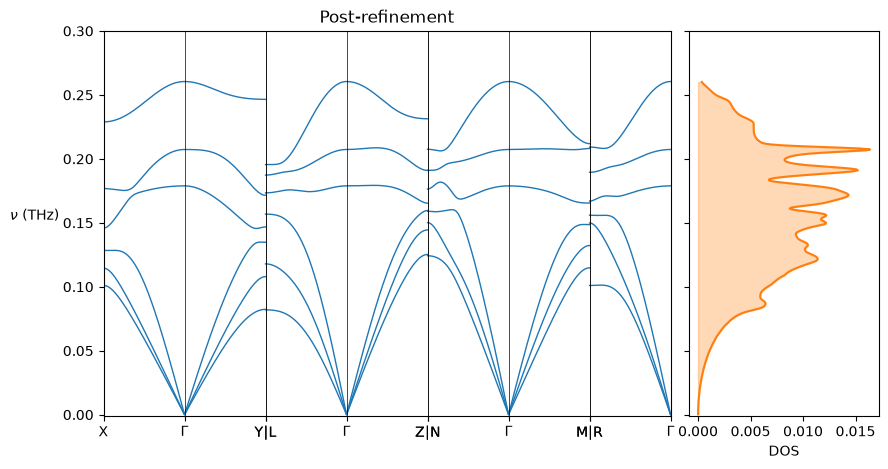

In [10]:
# ----------------------------------------------------------------------
# band path: X-Gamma-Y | L-Gamma-Z | N-Gamma-M | R-Gamma
# ----------------------------------------------------------------------

#Based on units of spring constants:
steve_factor = 10.0*np.sqrt(4.11/1.66)/(2*np.pi) #~15.7/2pi

#Labels taken directly from Meisburger (2020); may not match other notebooks.
HIGH_SYM_POINTS = {
    'G': np.array([0.0, 0.0, 0.0]),
    'L': np.array([0.0, 0.5,-0.5]),
    'M': np.array([0.5, 0.0, 0.0]),
    'N': np.array([0.5,-0.5,-0.5]),
    'R': np.array([0.5, 0.0,-0.5]),
    'X': np.array([0.0, 0.0,-0.5]),
    'Y': np.array([0.0, 0.5, 0.0]),
    'Z': np.array([0.5,-0.5, 0.0]),
}
PATH_SEQ = ['X', 'G', 'Y', '|', 'L', 'G', 'Z', '|', 'N', 'G', 'M', '|', 'R', 'G']

# 1. build df_atoms via space-group expansion
df_atoms = dynamat.build_df_atoms(st, groups)

# 2. rigid-body geometry: CM, generalized mass matrix, Cholesky
body_index, CM, L = dynamat.build_rigid_bodies(df_atoms)
M = len(body_index)
Linv = np.linalg.inv(L)

# 3. lattice / reciprocal lattice
lattice = dynamat.get_lattice(st.cell)
recip = dynamat.reciprocal_lattice(lattice)

# 4. df_symmetry already built elsewhere in pipeline
# df_symmetry = ...

sparse_L, sparse_T = dynamat.accumulate_sparse_blocks(df_symmetry, body_index, CM, lattice)

# 6. path, bands, plot
qs, xs, ticks, ticklabels, breaks = dynamat.build_path(recip, HIGH_SYM_POINTS, PATH_SEQ, n_per_segment=100)

# 5. placeholder spring constants -- one per symmetry class, replace
#    with refined values
classes = sorted(df_symmetry['spring_class'].unique())

kL = {w: springs_refinement[-1].T[1][w] for w in classes}
kT = {w: springs_refinement[-1].T[0][w] for w in classes}


bands = dynamat.compute_bands(qs, sparse_L, sparse_T, kL, kT, Linv, M)
#bands are \omega^2.
bands *= steve_factor**2
# 7. full-BZ FFT-grid machinery (rigid_body_dynmat.py), for DOS and for
#    2D dispersion images. Grid should be fine enough for a smooth DOS --
#    32^3 is a reasonable starting point; refine as needed.
grid_shape = (64,64,64)
sparse_blocks = dynamat.accumulate_sparse_grid_blocks(df_symmetry, body_index, CM, lattice, grid_shape)
D_grid = dynamat.build_D_grid_lowmem(sparse_blocks, kL, kT, L, grid_shape, dtype=np.float32)
eigs = dynamat.compute_all_eigs_from_grid(D_grid)            # (N1,N2,N3,6M)

# 8. DOS from the full grid, plotted alongside the path band structure
centers, dos = dynamat.compute_dos(eigs, n_bins=400, broaden_bins=2.0)
#centers are \omega; dos is modified by change of units and number of q points.
centers *= steve_factor
#normalize dos by # of q points.
dos /= (grid_shape[0]*grid_shape[1]*grid_shape[2])
#dos changes when units change.
# \int_{\omega_1}^{\omega_2}\rho_1(\omega)d\omega = \int_{\nu_1}^{\nu_2}\rho_2(\nu)d\nu => \rho_2(\nu) = (1/factor)*\rho_1(\omega).
dos /= steve_factor
dynamat.plot_bands_and_dos(bands, xs, ticks, ticklabels, -0.001, 0.3, breaks, centers, dos, ylabel= '$\\nu$ (THz)', title = 'Post-refinement', outfile = None)

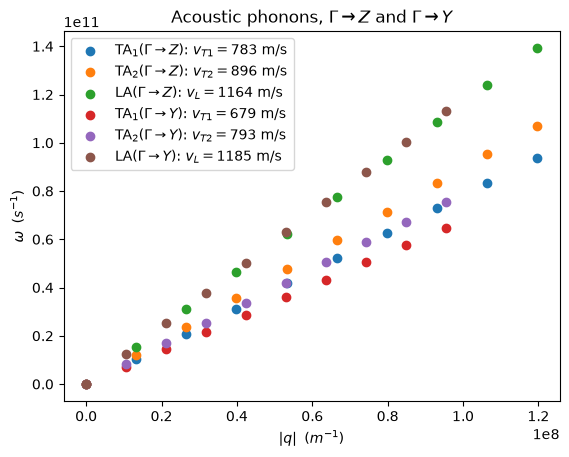

In [11]:
#For G->Z direction
x1s = np.linalg.norm(qs[301:311],axis=1)*(10**10)
ys1 = np.sqrt(np.abs(bands.T[0][301:311]))*2*np.pi*(10**12)
ys2 = np.sqrt(np.abs(bands.T[1][301:311]))*2*np.pi*(10**12)
ys3 = np.sqrt(np.abs(bands.T[2][301:311]))*2*np.pi*(10**12)

#For G->Y direction
x2s = np.linalg.norm(qs[100:110],axis=1)*(10**10)
ys4 = np.sqrt(np.abs(bands.T[0][100:110]))*2*np.pi*(10**12)
ys5 = np.sqrt(np.abs(bands.T[1][100:110]))*2*np.pi*(10**12)
ys6 = np.sqrt(np.abs(bands.T[2][100:110]))*2*np.pi*(10**12)

#Find sound speeds in G->Z direction
v1, b1 = np.polyfit(x1s, ys1, 1)
v2, b2 = np.polyfit(x1s, ys2, 1)
v3, b3 = np.polyfit(x1s, ys3, 1)

#Find sound speeds in G->Y direction
v4, b4 = np.polyfit(x2s, ys4, 1)
v5, b5 = np.polyfit(x2s, ys5, 1)
v6, b6 = np.polyfit(x2s, ys6, 1)

plt.scatter(x1s,ys1)
plt.scatter(x1s,ys2)
plt.scatter(x1s,ys3)

plt.scatter(x2s,ys4)
plt.scatter(x2s,ys5)
plt.scatter(x2s,ys6)
plt.xlabel('$|q|\\;\\;(m^{-1})$')
plt.ylabel('$\\omega\\;\\;(s^{-1})$')
plt.title('Acoustic phonons, $\\Gamma\\rightarrow Z$ and $\\Gamma\\rightarrow Y$')
plt.legend(['TA$_1$($\\Gamma\\rightarrow Z$): $v_{T1}=$'+f"{v1:.0f}"+' m/s',
            'TA$_2$($\\Gamma\\rightarrow Z$): $v_{T2}=$'+f"{v2:.0f}"+' m/s',
            'LA($\\Gamma\\rightarrow Z$): $v_{L}=$'+f"{v3:.0f}"+' m/s',
            'TA$_1$($\\Gamma\\rightarrow Y$): $v_{T1}=$'+f"{v4:.0f}"+' m/s',
            'TA$_2$($\\Gamma\\rightarrow Y$): $v_{T2}=$'+f"{v5:.0f}"+' m/s',
            'LA($\\Gamma\\rightarrow Y$): $v_{L}=$'+f"{v6:.0f}"+' m/s'])

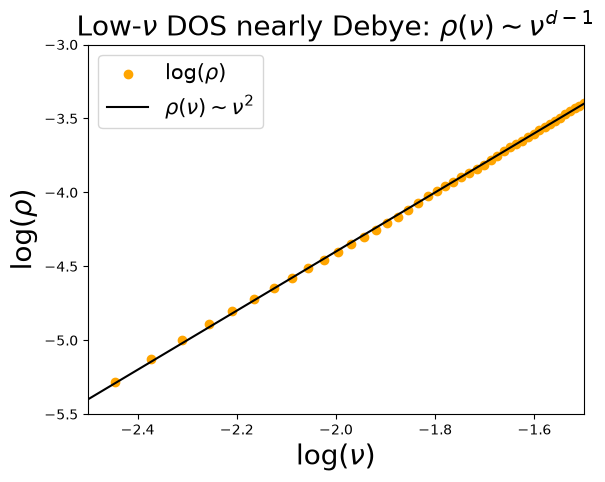

In [12]:
plt.scatter(np.log10(centers[:150]), np.log10(dos[:150]),c='orange')
xs = np.arange(-4,-1,0.001)
ys = 2*xs-0.4
plt.plot(xs,ys, c='k')
plt.xlim(-2.5,-1.5)
plt.ylim(-5.5,-3)
plt.xlabel('log($\\nu$)', fontsize=20)
plt.ylabel('log($\\rho$)', fontsize=20)
plt.legend(['log($\\rho$)', '$\\rho(\\nu)\\sim \\nu^{2}$'],fontsize=15)
plt.title('Low-$\\nu$ DOS nearly Debye: $\\rho(\\nu)\\sim\\nu^{d-1}$',fontsize=20);
plt.savefig('20260812_lysozyme_dos_debye.png', dpi=300)

In [13]:
def specific_heat(kTohs, dos, centers):
    dn = centers[1]-centers[0]
    Cok = np.zeros(len(kTohs))
    for i in range(len(kTohs)):
        for j in range(len(centers)):
            Cok[i] += (kTohs[i]**-2)*dos[j]*(centers[j]**2)*(np.exp(centers[j]/kTohs[i]))/((np.exp(centers[j]/kTohs[i])-1)**2)*dn
    return Cok

In [14]:
kTohs = np.arange(0.0005,0.3,0.0001)
Cok = specific_heat(kTohs, dos, centers)

/tmp/ipykernel_476/3955502516.py:6: RuntimeWarning: overflow encountered in scalar power
  Cok[i] += (kTohs[i]**-2)*dos[j]*(centers[j]**2)*(np.exp(centers[j]/kTohs[i]))/((np.exp(centers[j]/kTohs[i])-1)**2)*dn


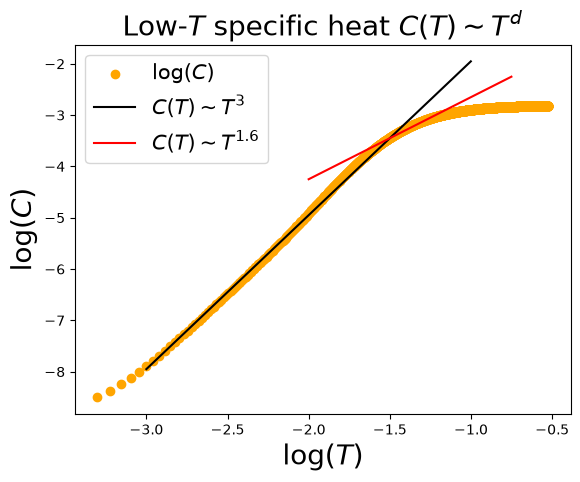

In [15]:
plt.scatter(np.log10(kTohs), np.log10(Cok),c='orange')
xs = np.arange(-3,-1,0.001)
ys = 3*xs+1.05
plt.plot(xs,ys, c='k')
x2s = np.arange(-2,-0.75,0.001)
y2s = 1.6*x2s-1.05
plt.plot(x2s,y2s, c='r')
# plt.xlim(-3.5,-1)
# plt.ylim(-3,4)
plt.xlabel('log($T$)', fontsize=20)
plt.ylabel('log($C$)', fontsize=20)
plt.legend(['log($C$)', '$C(T)\\sim T^{3}$', '$C(T)\\sim T^{1.6}$'],fontsize=15)
plt.title('Low-$T$ specific heat $C(T)\\sim T^{d}$',fontsize=20);
plt.savefig('20260812_lysozyme_CV_debye.png', dpi=300)

In [16]:
# import glob
# from PIL import Image

# def make_gif(frame_folder, output_path="animation.gif", duration=200):
#     # 1. Grab all PNG files in the specified folder and sort them alphabetically
#     # Sorting ensures your frames play in the correct chronological order
#     frame_files = sorted(glob.glob(f"{frame_folder}/*.png"))
    
#     # 2. Open all images and store them in a list
#     frames = [Image.open(image) for image in frame_files]
    
#     # 3. Guard against empty folders
#     if not frames:
#         print(f"No PNG images found in '{frame_folder}'")
#         return

#     # 4. Save the frames as an animated GIF
#     # Use the first image as the base and append the rest
#     frames[0].save(
#         output_path,
#         format="GIF",
#         append_images=frames[1:],
#         save_all=True,
#         duration=duration,  # Time per frame in milliseconds (e.g., 200ms = 5 frames per second)
#         loop=0              # 0 means infinite loop. Pass None for no loop.
#     )
#     print(f"GIF successfully saved to {output_path}")

# # Example Usage:
# # Assumes you have a folder called "my_frames" filled with PNGs
# durations = [150 for i in range(78)]
# durations[-1] = 6000
# make_gif(frame_folder="bandstructures", output_path="band_structure.gif", duration=durations)

In [17]:
steve_bands = pd.read_csv('lattice_dispersion.csv')

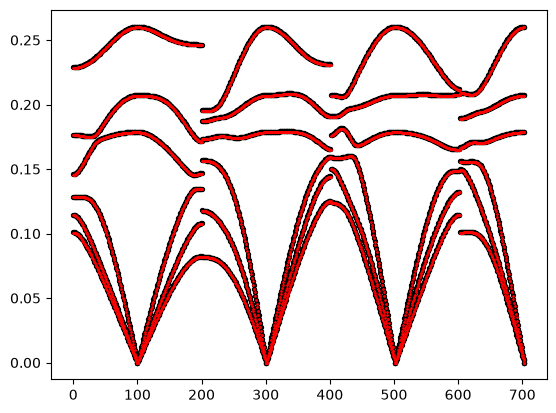

In [18]:
plt.scatter(np.arange(704),np.sqrt(np.abs(bands)).T[0],s=8,c='k')
plt.scatter(np.arange(704),np.sqrt(np.abs(bands)).T[1],s=8,c='k')
plt.scatter(np.arange(704),np.sqrt(np.abs(bands)).T[2],s=8,c='k')
plt.scatter(np.arange(704),np.sqrt(np.abs(bands)).T[3],s=8,c='k')
plt.scatter(np.arange(704),np.sqrt(np.abs(bands)).T[4],s=8,c='k')
plt.scatter(np.arange(704),np.sqrt(np.abs(bands)).T[5],s=8,c='k')
plt.scatter(np.arange(707)*704/707,np.array(steve_bands['frequency_1']),s=1,c='r')
plt.scatter(np.arange(707)*704/707,np.array(steve_bands['frequency_2']),s=1,c='r')
plt.scatter(np.arange(707)*704/707,np.array(steve_bands['frequency_3']),s=1,c='r')
plt.scatter(np.arange(707)*704/707,np.array(steve_bands['frequency_4']),s=1,c='r')
plt.scatter(np.arange(707)*704/707,np.array(steve_bands['frequency_5']),s=1,c='r')
plt.scatter(np.arange(707)*704/707,np.array(steve_bands['frequency_6']),s=1,c='r')